# Eksploracja po normalizacji katalogu Zurada

Notebook opisuje dane z `zurada_products_with_metadata_cleaned.csv` po normalizacji metadanych.

In [1]:
%pip install pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

CSV = "zurada_products_with_metadata_cleaned.csv"
df  = pd.read_csv(CSV)

LIST_COLS   = ["dozwolone_powierzchnie", "odradzane_powierzchnie",
               "metoda_mycia", "zgodnosc_i_certyfikaty", "ostrzezenia_bhp"]
STRING_COLS = ["odczyn_ph"]

def parse_list(val):
    if pd.isna(val) or str(val).strip() == "":
        return []
    try:
        parsed = json.loads(val)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except Exception:
        return [str(val)]

def col_counter(col):
    c = Counter()
    for v in df[col].dropna():
        c.update(parse_list(v))
    return c

print(f"Wczytano {len(df)} produktów, {len(df.columns)} kolumn.")
df[["product_id","product_name","title"]].head(5)

Matplotlib is building the font cache; this may take a moment.


Wczytano 100 produktów, 14 kolumn.


,product_id,product_name,title
0,1,Zurada Lśniąca Pianka,Pianka do powierzchni
1,2,Zurada Szklany Blask,Płyn do szyb i luster
2,3,Zurada Tłuszcz Stop,Płyn do odtłuszczania
3,4,Zurada Kuchnia Czysta,Płyn odtłuszczający do kuchni
4,5,Zurada Piana Moc,Pianka do piekarników


## 1. Przegląd ogólny

In [3]:
print("=== Braki danych ===")
missing = df[LIST_COLS + STRING_COLS].apply(
    lambda col: col.apply(lambda v: not parse_list(v) if col.name in LIST_COLS else (pd.isna(v) or str(v).strip() == "")).sum()
)
for col, cnt in missing.items():
    pct = cnt / len(df) * 100
    status = "⚠️" if pct > 20 else "✓"
    print(f"  {status}  {col:<30} {cnt:3d} pustych  ({pct:.0f}%)")

=== Braki danych ===
  ✓  dozwolone_powierzchnie           2 pustych  (2%)
  ⚠️  odradzane_powierzchnie          46 pustych  (46%)
  ✓  metoda_mycia                     5 pustych  (5%)
  ⚠️  zgodnosc_i_certyfikaty          51 pustych  (51%)
  ⚠️  ostrzezenia_bhp                 26 pustych  (26%)
  ⚠️  odczyn_ph                       75 pustych  (75%)


In [4]:
print("=== Liczba unikalnych wartości per kolumna ===")
for col in LIST_COLS:
    n = len(col_counter(col))
    print(f"  {col:<30} {n:3d} unikalnych")
print(f"  {'odczyn_ph':<30} {df['odczyn_ph'].nunique():3d} unikalnych")

=== Liczba unikalnych wartości per kolumna ===
  dozwolone_powierzchnie         201 unikalnych
  odradzane_powierzchnie          48 unikalnych
  metoda_mycia                    23 unikalnych
  zgodnosc_i_certyfikaty          20 unikalnych
  ostrzezenia_bhp                 63 unikalnych
  odczyn_ph                        5 unikalnych


## 2. Metody mycia

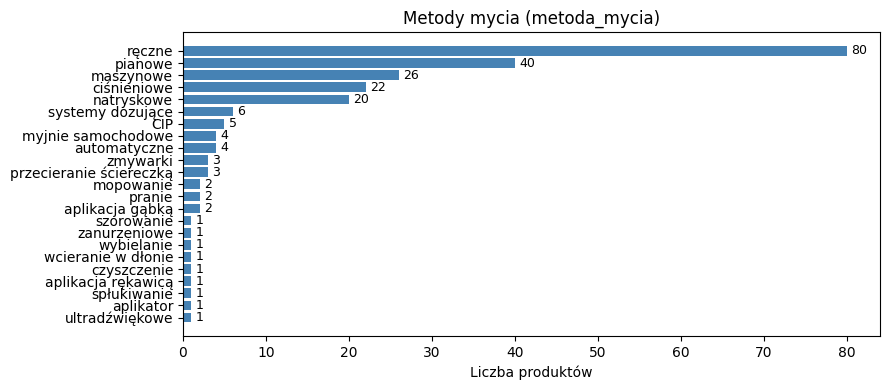

Łącznie 23 unikalnych metod.


In [5]:
c = col_counter("metoda_mycia")
labels, values = zip(*c.most_common())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels[::-1], values[::-1], color="steelblue")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Liczba produktów")
ax.set_title("Metody mycia (metoda_mycia)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()
print(f"Łącznie {len(c)} unikalnych metod.")

## 3. Odczyn pH

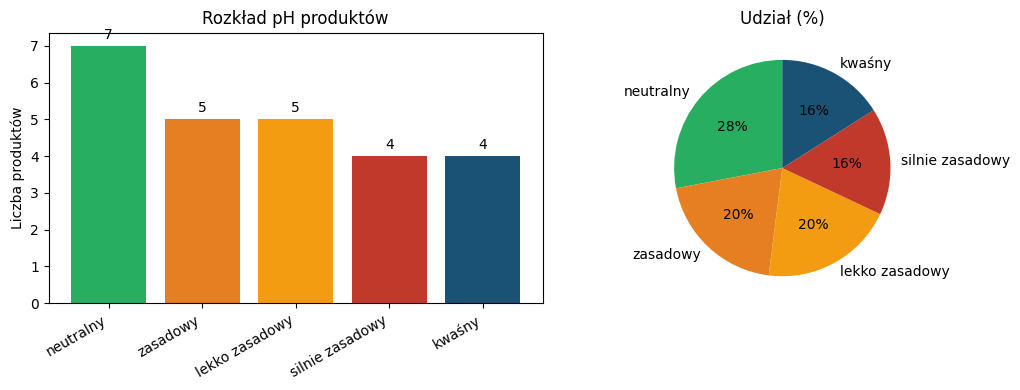

Produkty bez zdefiniowanego pH: 150


In [6]:
ph = df["odczyn_ph"].dropna()
ph = ph[ph.str.strip() != ""]
counts = ph.value_counts()

COLORS = {
    "silnie zasadowy": "#c0392b", "zasadowy": "#e67e22", "lekko zasadowy": "#f39c12",
    "neutralny": "#27ae60", "lekko kwaśny": "#2980b9", "kwaśny": "#1a5276",
    "silnie kwaśny": "#0d1b2a",
}
colors = [COLORS.get(k, "gray") for k in counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bars = ax1.bar(counts.index, counts.values, color=colors)
ax1.bar_label(bars, padding=3)
ax1.set_title("Rozkład pH produktów")
ax1.set_ylabel("Liczba produktów")
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax2.pie(counts.values, labels=counts.index, colors=colors,
        autopct="%1.0f%%", startangle=90)
ax2.set_title("Udział (%)")

plt.tight_layout()
plt.show()
print(f"Produkty bez zdefiniowanego pH: {df['odczyn_ph'].isna().sum() + (df['odczyn_ph'].fillna('').str.strip() == '').sum()}")

## 4. Dozwolone powierzchnie (Top 20)

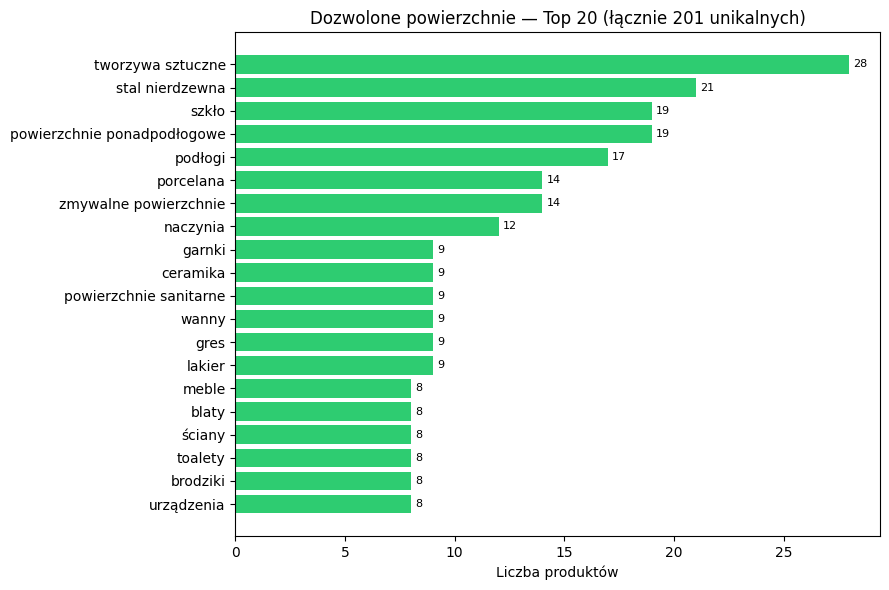

In [7]:
c = col_counter("dozwolone_powierzchnie")
top = c.most_common(20)
labels, values = zip(*top)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels[::-1], values[::-1], color="#2ecc71")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Liczba produktów")
ax.set_title(f"Dozwolone powierzchnie — Top 20 (łącznie {len(c)} unikalnych)")
plt.tight_layout()
plt.show()

## 5. Odradzane powierzchnie — mapa ryzyka

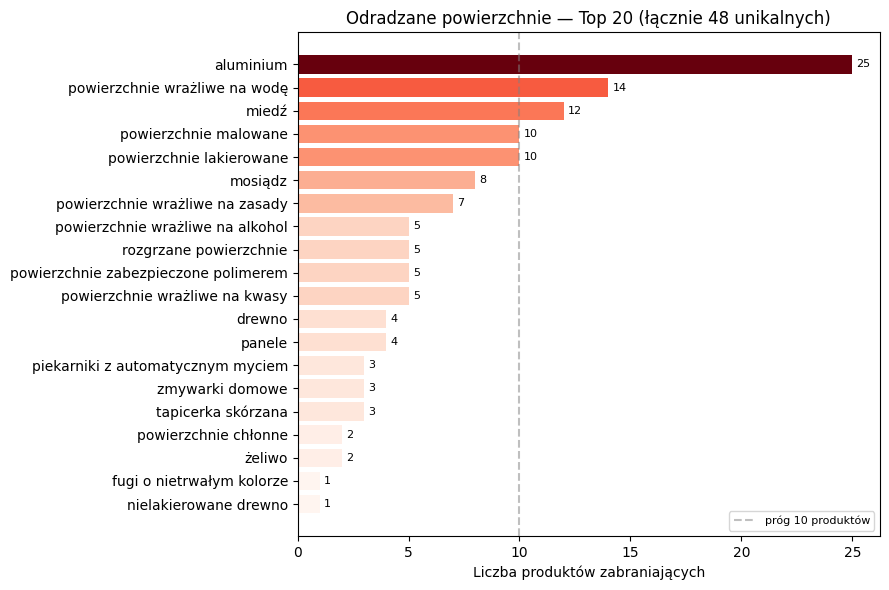


KRYTYCZNE ZAKAZY (≥10 produktów):
  ⛔   25 produktów — NIE stosować na: aluminium
  ⛔   14 produktów — NIE stosować na: powierzchnie wrażliwe na wodę
  ⛔   12 produktów — NIE stosować na: miedź
  ⛔   10 produktów — NIE stosować na: powierzchnie malowane
  ⛔   10 produktów — NIE stosować na: powierzchnie lakierowane


In [8]:
c = col_counter("odradzane_powierzchnie")
top = c.most_common(20)
labels, values = zip(*top)

fig, ax = plt.subplots(figsize=(9, 6))
# Gradient kolorów: im więcej produktów zabrania — tym ciemniej czerwony
norm = plt.Normalize(min(values), max(values))
colors = plt.cm.Reds(norm(list(values[::-1])))
bars = ax.barh(labels[::-1], values[::-1], color=colors)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Liczba produktów zabraniających")
ax.set_title(f"Odradzane powierzchnie — Top 20 (łącznie {len(c)} unikalnych)")
ax.axvline(x=10, color="gray", linestyle="--", alpha=0.5, label="próg 10 produktów")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Tekstowe podsumowanie krytycznych zakazów
print("\nKRYTYCZNE ZAKAZY (≥10 produktów):")
for label, val in top:
    if val >= 10:
        print(f"  ⛔  {val:3d} produktów — NIE stosować na: {label}")

## 6. Certyfikaty i zgodności

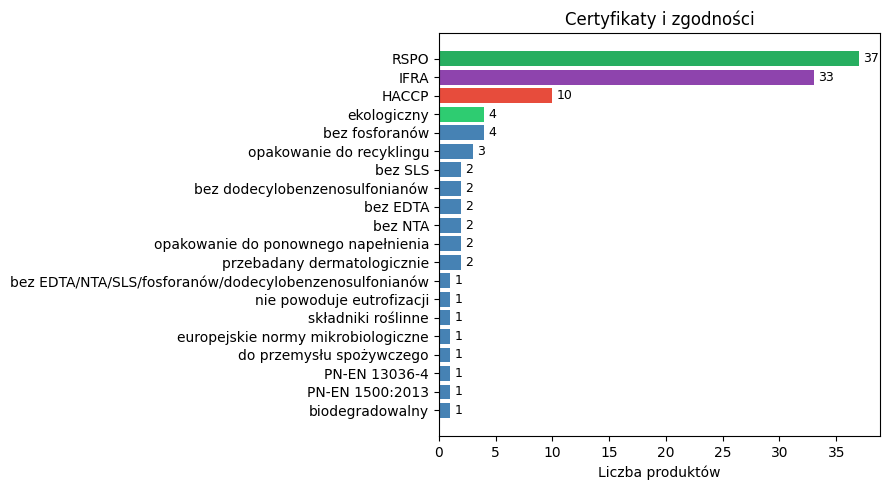


Podsumowanie:
   37 produktów — RSPO
   33 produktów — IFRA
   10 produktów — HACCP
    4 produktów — ekologiczny
    4 produktów — bez fosforanów
    3 produktów — opakowanie do recyklingu
    2 produktów — bez SLS
    2 produktów — bez dodecylobenzenosulfonianów
    2 produktów — bez EDTA
    2 produktów — bez NTA
    2 produktów — opakowanie do ponownego napełnienia
    2 produktów — przebadany dermatologicznie
    1 produktów — bez EDTA/NTA/SLS/fosforanów/dodecylobenzenosulfonianów
    1 produktów — nie powoduje eutrofizacji
    1 produktów — składniki roślinne
    1 produktów — europejskie normy mikrobiologiczne
    1 produktów — do przemysłu spożywczego
    1 produktów — PN-EN 13036-4
    1 produktów — PN-EN 1500:2013
    1 produktów — biodegradowalny


In [9]:
c = col_counter("zgodnosc_i_certyfikaty")
top = c.most_common()
labels, values = zip(*top)

CERT_COLORS = {
    "RSPO": "#27ae60", "IFRA": "#8e44ad", "HACCP": "#e74c3c",
    "EU Ecolabel": "#27ae60", "ekologiczny": "#2ecc71",
}
colors = [CERT_COLORS.get(l, "steelblue") for l in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Liczba produktów")
ax.set_title("Certyfikaty i zgodności")
plt.tight_layout()
plt.show()

print("\nPodsumowanie:")
for l, v in top:
    print(f"  {v:3d} produktów — {l}")

## 7. Ostrzeżenia BHP (Top 15)

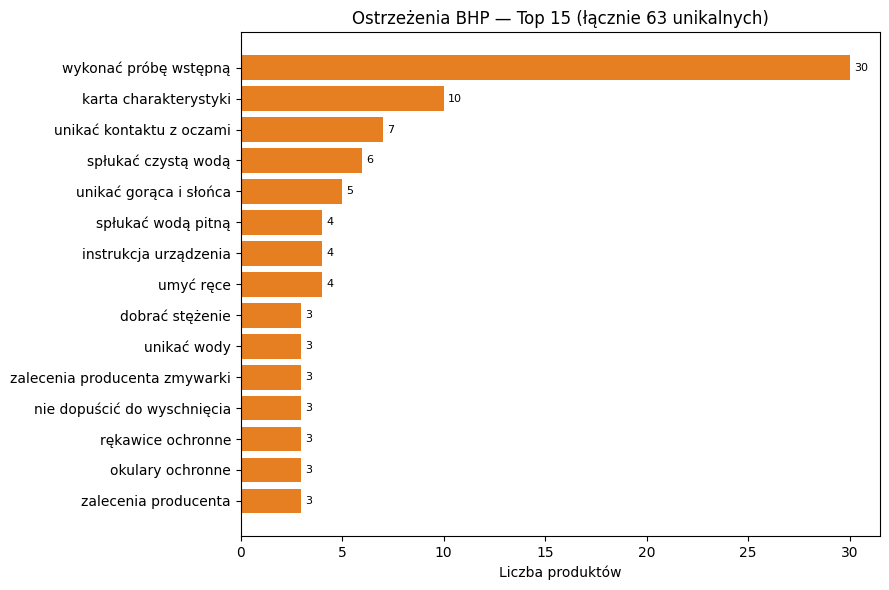

In [10]:
c = col_counter("ostrzezenia_bhp")
top = c.most_common(15)
labels, values = zip(*top)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels[::-1], values[::-1], color="#e67e22")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Liczba produktów")
ax.set_title(f"Ostrzeżenia BHP — Top 15 (łącznie {len(c)} unikalnych)")
plt.tight_layout()
plt.show()

## 9. Kategorie sklepowe

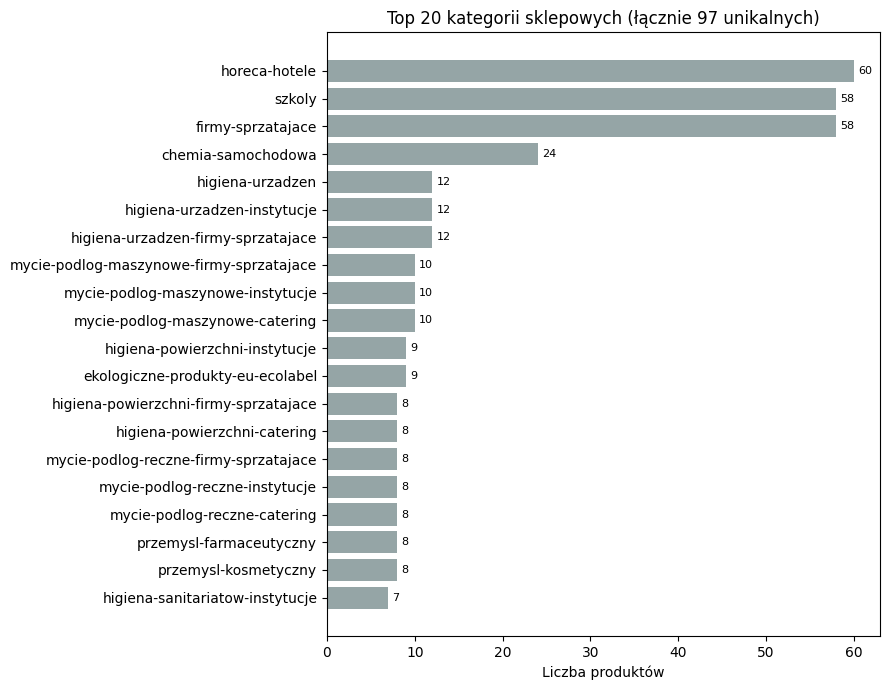

In [14]:
cat_counter = Counter()
for row in df["categories"].dropna():
    cats = [c.strip() for c in str(row).split(",") if c.strip()]
    cat_counter.update(cats)

top_cats = cat_counter.most_common(20)
labels, values = zip(*top_cats)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(labels[::-1], values[::-1], color="#95a5a6")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Liczba produktów")
ax.set_title(f"Top 20 kategorii sklepowych (łącznie {len(cat_counter)} unikalnych)")
plt.tight_layout()
plt.show()

## 10. Macierz: pH × metoda mycia

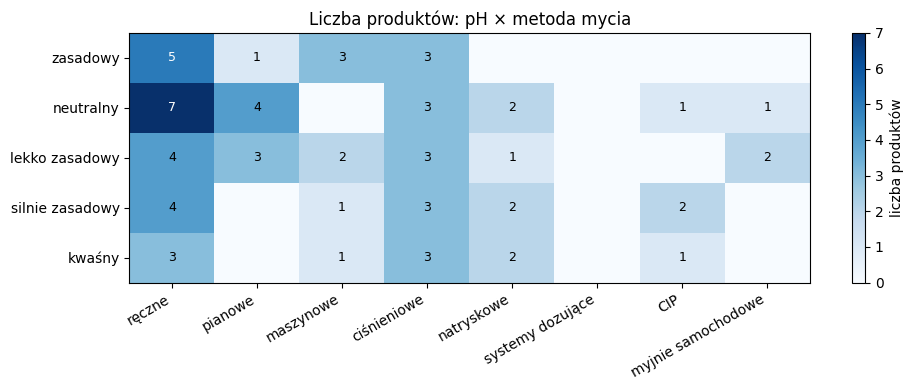

In [15]:
import numpy as np

ph_vals     = [v for v in df["odczyn_ph"].dropna().unique() if str(v).strip()]
metody      = [k for k, _ in col_counter("metoda_mycia").most_common(8)]

matrix = pd.DataFrame(0, index=ph_vals, columns=metody)

for _, row in df.iterrows():
    ph = row["odczyn_ph"]
    if pd.isna(ph) or str(ph).strip() == "":
        continue
    methods = parse_list(row["metoda_mycia"])
    for m in methods:
        if m in metody:
            matrix.loc[ph, m] += 1

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(matrix.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(metody)))
ax.set_xticklabels(metody, rotation=30, ha="right")
ax.set_yticks(range(len(ph_vals)))
ax.set_yticklabels(ph_vals)
ax.set_title("Liczba produktów: pH × metoda mycia")
plt.colorbar(im, ax=ax, label="liczba produktów")
for i in range(len(ph_vals)):
    for j in range(len(metody)):
        v = matrix.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                    color="white" if v > matrix.values.max() * 0.6 else "black")
plt.tight_layout()
plt.show()

## 11. Wyszukiwarka produktów po metadanych

In [16]:
# ── Ustaw filtry poniżej ──────────────────────────────────────────────────────
FILTER_METODA        = "maszynowe"   # lub None
FILTER_CERTYFIKAT    = "HACCP"       # lub None
FILTER_PH            = None          # np. "zasadowy" lub None
EXCLUDE_POWIERZCHNIA = "aluminium"   # odradzane — lub None
# ─────────────────────────────────────────────────────────────────────────────

mask = pd.Series([True] * len(df), index=df.index)

if FILTER_METODA:
    mask &= df["metoda_mycia"].apply(lambda v: FILTER_METODA in parse_list(v))
if FILTER_CERTYFIKAT:
    mask &= df["zgodnosc_i_certyfikaty"].apply(lambda v: FILTER_CERTYFIKAT in parse_list(v))
if FILTER_PH:
    mask &= df["odczyn_ph"].fillna("") == FILTER_PH
if EXCLUDE_POWIERZCHNIA:
    mask &= ~df["odradzane_powierzchnie"].apply(lambda v: EXCLUDE_POWIERZCHNIA in parse_list(v))

result = df[mask][["product_id", "product_name", "odczyn_ph", "metoda_mycia", "zgodnosc_i_certyfikaty"]]
print(f"Znaleziono {len(result)} produktów spełniających filtry:")
print(f"  metoda={FILTER_METODA}, certyfikat={FILTER_CERTYFIKAT}, pH={FILTER_PH}, wyklucz={EXCLUDE_POWIERZCHNIA}")
result

Znaleziono 2 produktów spełniających filtry:
  metoda=maszynowe, certyfikat=HACCP, pH=None, wyklucz=aluminium


,product_id,product_name,odczyn_ph,metoda_mycia,zgodnosc_i_certyfikaty
20,21,Zurada Krystal Błysk,NaN,"[""maszynowe"", ""systemy dozujące""]","[""HACCP"", ""RSPO""]"
56,57,Zurada Czysty Blask,NaN,"[""maszynowe"", ""ręczne"", ""pianowe""]","[""HACCP"", ""IFRA"", ""RSPO""]"
